XGBoost Next-Hour Demand Forecast
---------------------------------
Training rows (<= 2023): 79289
Test rows (2024): 9145
MAE: 404.76 MW
RMSE: 1962.02 MW
R2: 0.5475
MAPE: 5.26%

Feature importances:
          feature  importance
0       demand_mw    0.541761
1   generation_mw    0.313974
2      deficit_mw    0.051274
10            day    0.027741
6     liquid_fuel    0.027577
9            hour    0.013054
11          month    0.009300
5           hydro    0.007125
3           solar    0.004396
4            wind    0.003798
7     india_adani    0.000000
8           nepal    0.000000

Saved model to C:\Users\Daksh\Downloads\AI Recruitment\notebooks\xgboost_demand_forecast.pkl

Sample predictions:
                     actual_next_hour_demand_mw  predicted_next_hour_demand_mw
datetime                                                                      
2024-01-01 00:00:00                      7259.0                    7176.299316
2024-01-01 01:00:00                      7010.0            

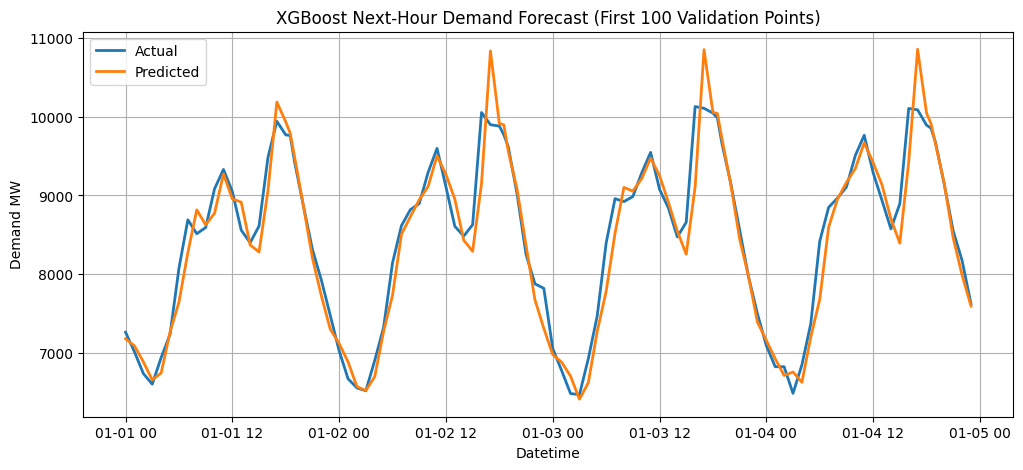

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor
import joblib

file_path = Path('PGCB_cleaned_power_data.csv')
df = pd.read_csv(file_path, parse_dates=['datetime'])
df = df.sort_values('datetime').set_index('datetime')

df['demand_mw'] = df['demand_mw'].ffill()

train_year = 2023
test_year = 2024
df = df[df.index.year <= test_year].copy()

if 'target_demand_mw' in df.columns:
    df = df.drop(columns=['target_demand_mw'])
df['target_demand_mw'] = df['demand_mw'].shift(-1)
df = df.dropna(subset=['target_demand_mw'])

feature_columns = [
    'demand_mw',
    'generation_mw',
    'deficit_mw',
    'solar',
    'wind',
    'hydro',
    'thermal',
    'liquid_fuel',
    'india_adani',
    'nepal',
    'hour',
    'day',
    'month'
]
feature_columns = [col for col in feature_columns if col in df.columns]

train_df = df[df.index.year <= train_year]
test_df = df[df.index.year >= test_year]

if test_df.empty:
    raise ValueError(f'No data found for the test year {test_year}')

X_train = train_df[feature_columns]
y_train = train_df['target_demand_mw']
X_test = test_df[feature_columns]
y_test = test_df['target_demand_mw']

model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

model.fit(
    X_train,
    y_train,
    verbose=False
)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('XGBoost Next-Hour Demand Forecast')
print('---------------------------------')
print(f'Training rows (<= {train_year}): {len(X_train)}')
print(f'Test rows ({test_year}): {len(X_test)}')
print(f'MAE: {mae:.2f} MW')
print(f'RMSE: {rmse:.2f} MW')
print(f'R2: {r2:.4f}')
print(f'MAPE: {mape:.2f}%')

importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print('\nFeature importances:')
print(importance_df)

model_path = Path('xgboost_demand_forecast.pkl')
joblib.dump(model, model_path)
print(f'\nSaved model to {model_path.resolve()}')

results = X_test.copy()
results['actual_next_hour_demand_mw'] = y_test
results['predicted_next_hour_demand_mw'] = y_pred
results = results[['actual_next_hour_demand_mw', 'predicted_next_hour_demand_mw']]
print('\nSample predictions:')
print(results.head(10))

plt.figure(figsize=(12, 5))
plt.plot(results.index[:100], results['actual_next_hour_demand_mw'][:100], label='Actual', linewidth=2)
plt.plot(results.index[:100], results['predicted_next_hour_demand_mw'][:100], label='Predicted', linewidth=2)
plt.title('XGBoost Next-Hour Demand Forecast (First 100 Validation Points)')
plt.xlabel('Datetime')
plt.ylabel('Demand MW')
plt.legend()
plt.grid(True)
plt.show()
